# Load Data

In [176]:
import sys
sys.path.append('../src')
import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"  
import mrcfile
import numpy as np
import skimage

shape = "74_SS1_normalized"
data_dir = "Jake_Cropped"

normalized_path = f"../data/{data_dir}/{shape}.mrc"
with mrcfile.open(normalized_path, permissive=True) as mrc:
    norm_data = mrc.data.astype(np.float32)

In [177]:
import napari
import numpy as np

def napari_gradient(data):
    # binary mask: shape (Z, Y, X)
    mask = data.astype(np.float32)

    # 중심 좌표 계산
    z0, y0, x0 = np.array(mask.shape) / 2

    # 각 voxel의 거리 계산
    zz, yy, xx = np.meshgrid(
        np.arange(mask.shape[0]),
        np.arange(mask.shape[1]),
        np.arange(mask.shape[2]),
        indexing="ij"
    )

    distance = np.sqrt((zz - z0)**2 + (yy - y0)**2 + (xx - x0)**2)

    # 거리 정규화: 0.2 ~ 1.0 사이로 스케일링
    distance_norm = 0.2 + 0.8 * (distance / distance.max())

    # gradient mask 생성
    gradient_mask = mask * distance_norm ** 2

    # napari 시각화
    viewer = napari.Viewer()
    viewer.add_image(gradient_mask.astype(np.float32), name="Center-Distance Gradient", colormap="twilight", blending="translucent", opacity=0.5)
    napari.run()

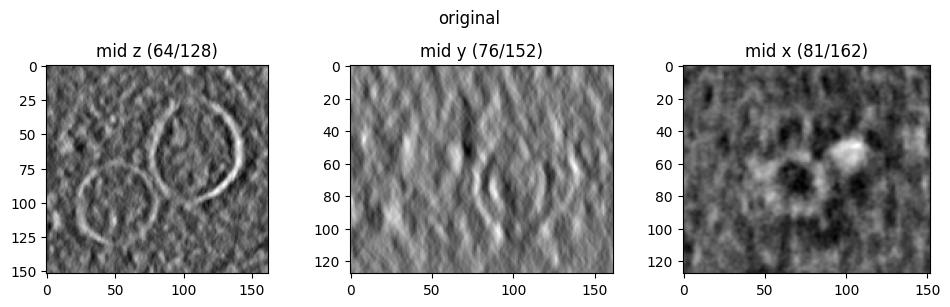

In [178]:
from pinn.plot import visualize_zyx_midslice, visualize_zyx_midslice_vs_overlay

visualize_zyx_midslice(norm_data, title="original")

### Bandpass Filtering

In [11]:
from scipy.fft import fftn, ifftn, fftshift
import numpy as np

def bandpass_filter_3d(vol, low, high):
    F = fftshift(fftn(vol))
    nx, ny, nz = vol.shape
    X, Y, Z = np.ogrid[-nx//2:nx//2, -ny//2:ny//2, -nz//2:nz//2]
    R = np.sqrt(X**2 + Y**2 + Z**2)
    mask = (R > nx*low) & (R < nx*high)
    return np.real(ifftn(np.fft.ifftshift(F * mask)))

Data min: -0.45961672
Data max: 0.53971434
Normalized data min: 0.0
Normalized data max: 1.0


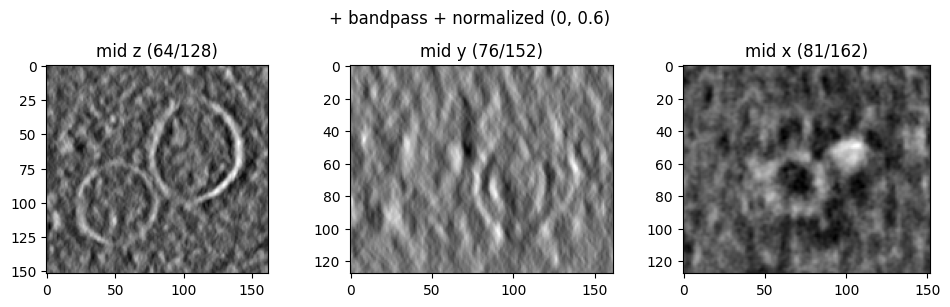

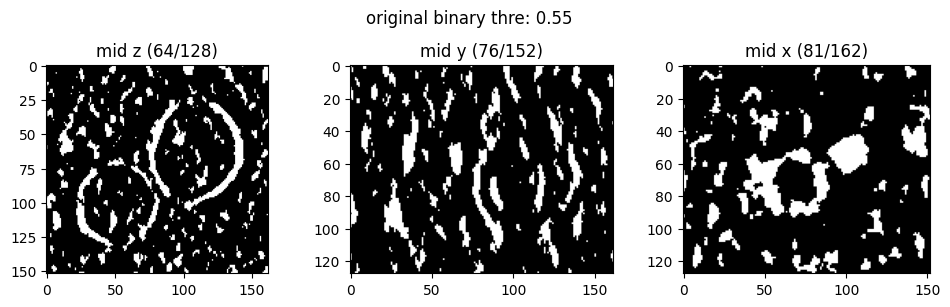

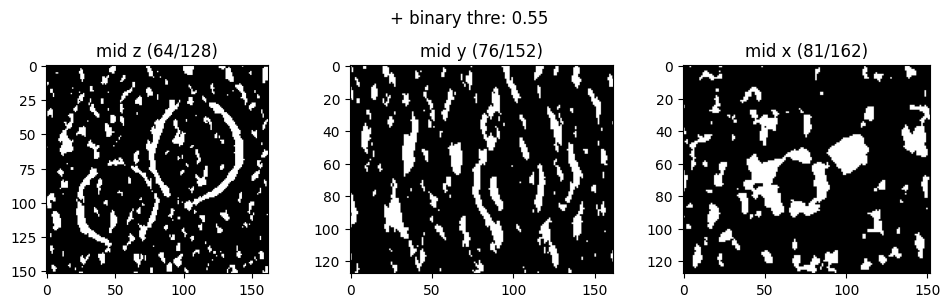

In [181]:
hi = 0.6
thre = 0.55
bandpass = bandpass_filter_3d(norm_data, 0, hi)

norm_min, norm_max = 0.0, 1.0
data_min = np.min(bandpass)
data_max = np.max(bandpass)
print("Data min:", data_min)
print("Data max:", data_max)
bandpass_normalized = (bandpass - data_min) / (data_max - data_min)
bandpass_normalized = bandpass_normalized * (norm_max - norm_min) + norm_min
print("Normalized data min:", np.min(bandpass_normalized))
print("Normalized data max:", np.max(bandpass_normalized))

visualize_zyx_midslice(bandpass_normalized, title=f"+ bandpass + normalized (0, {hi})")
binary_ori = np.where(norm_data > thre, 1, 0)
visualize_zyx_midslice(binary_ori, title=f"original binary thre: {thre}")
binary_bandpass = np.where(bandpass_normalized > thre, 1, 0)
visualize_zyx_midslice(binary_bandpass, title=f"+ binary thre: {thre}")

### Erosion-Dilation

In [ ]:
import numpy as np
from skimage.morphology import ball, binary_closing, binary_opening, remove_small_objects
from skimage.measure import label

# 1. closing: dilation --> erosion / connect / r=1: 3 voxel radius
# 2. opening: erosion --> dilation / remove small particles & noise / use same or smaller r
maskR = 3
thick_mask = binary_opening(binary_bandpass, ball(maskR))
thick_mask = binary_closing(thick_mask, ball(maskR))
visualize_zyx_midslice(thick_mask, title="Thick Mask")

dataR = 1
plane = np.where(thick_mask > 0, 0, binary_bandpass)
visualize_zyx_midslice(plane, title=f"+ Masking (r={maskR})")

plane = binary_closing(plane, ball(dataR))
visualize_zyx_midslice(plane, title=f"+ dilation-erosion (r={dataR})")

plane = binary_opening(plane, ball(dataR))
visualize_zyx_midslice(plane, title=f"+ erosion-dilation (r={dataR})")

min_size = 3000
plane = remove_small_objects(plane, min_size=min_size, connectivity=3)
visualize_zyx_midslice(plane, title=f"+ remove_small_objects (size={min_size})")


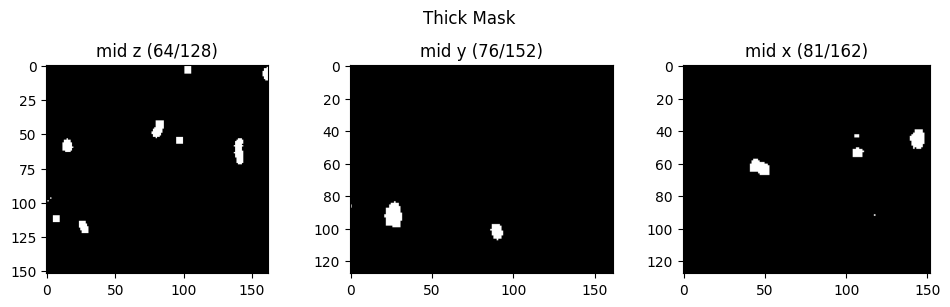

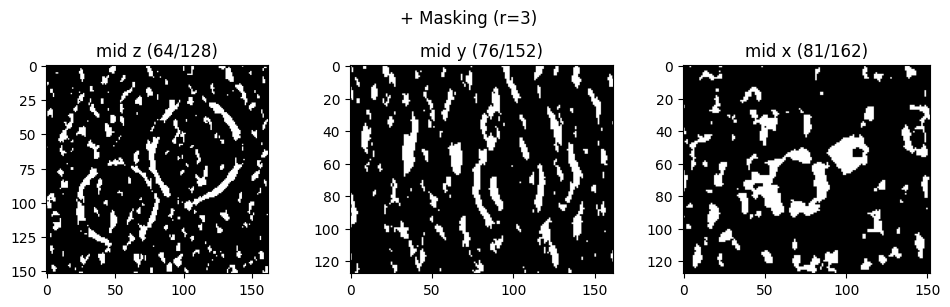

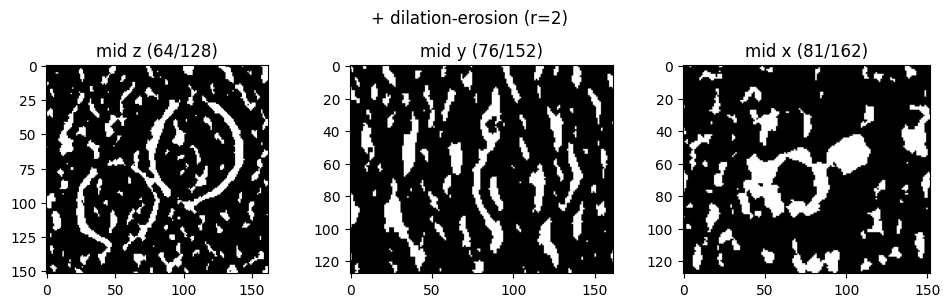

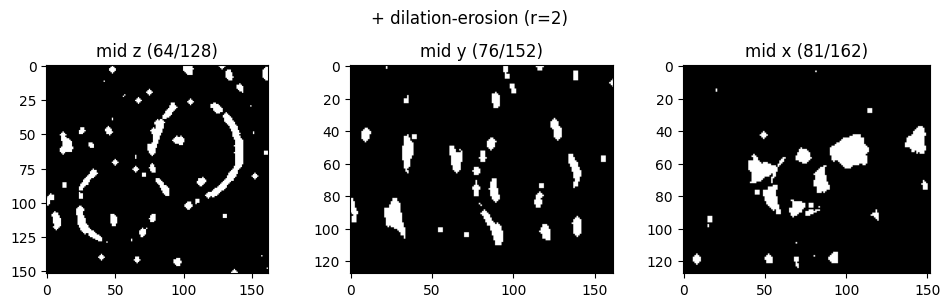

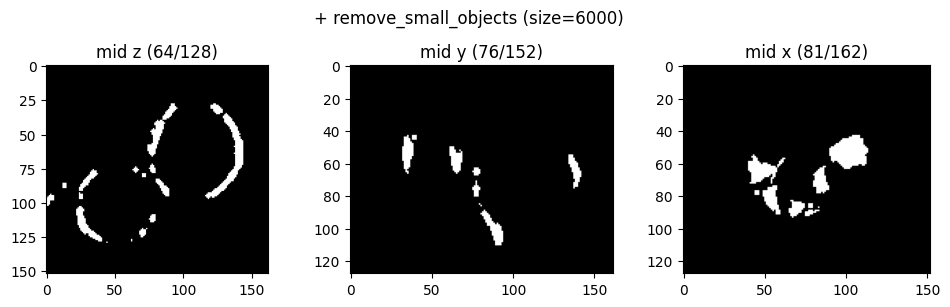

In [227]:
import numpy as np
from skimage.morphology import ball, binary_closing, binary_opening, remove_small_objects
from skimage.measure import label

# 1. closing: dilation --> erosion / connect / r=1: 3 voxel radius
# 2. opening: erosion --> dilation / remove small particles & noise / use same or smaller r
maskR = 3
thick_mask = binary_opening(binary_bandpass, ball(maskR))
thick_mask = binary_closing(thick_mask, ball(maskR))
visualize_zyx_midslice(thick_mask, title="Thick Mask")

dataR = 2
plane = np.where(thick_mask > 0, 0, binary_bandpass)
visualize_zyx_midslice(plane, title=f"+ Masking (r={maskR})")

plane = binary_closing(binary_bandpass, ball(dataR))
visualize_zyx_midslice(plane, title=f"+ dilation-erosion (r={dataR})")

plane = binary_opening(binary_bandpass, ball(dataR))
visualize_zyx_midslice(plane, title=f"+ dilation-erosion (r={dataR})")

min_size = 6000
plane = remove_small_objects(plane, min_size=min_size, connectivity=3)
visualize_zyx_midslice(plane, title=f"+ remove_small_objects (size={min_size})")


In [175]:
preprocessed_path = f"../data/{data_dir}/{shape}_preprocessed.mrc"

with mrcfile.new(preprocessed_path, overwrite=True) as mrc:
    mrc.set_data(plane.astype(np.float32))

### Morphology Filtering

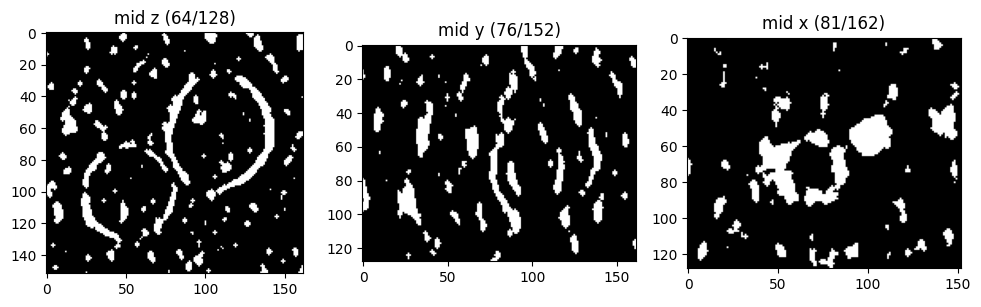

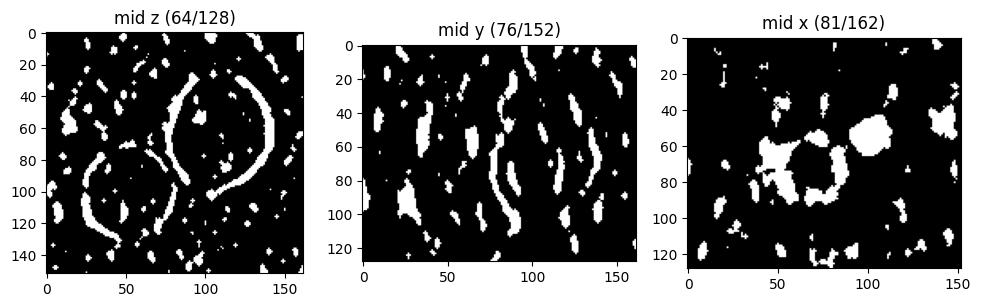

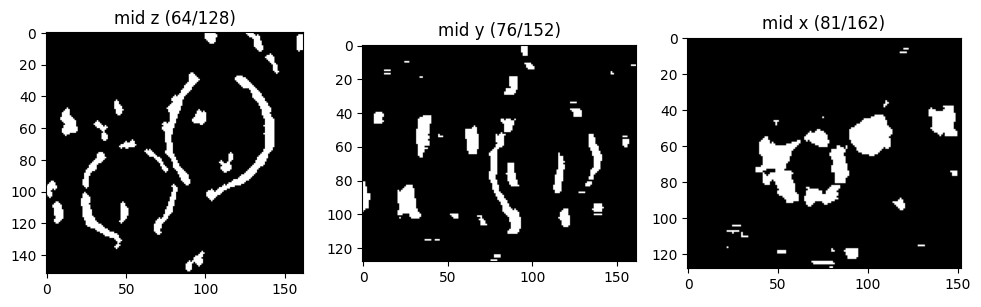

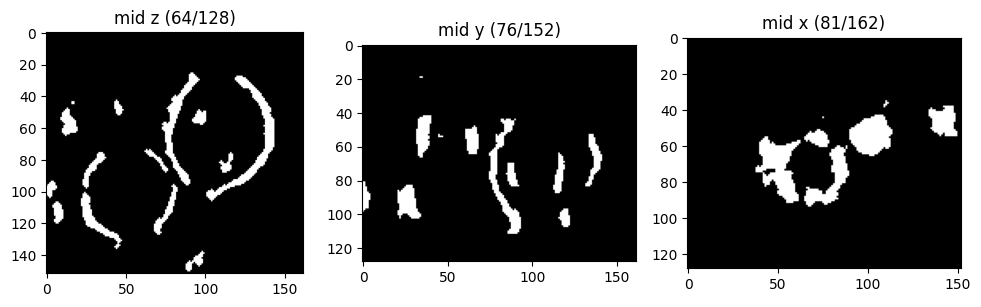

29


In [200]:
from skimage.morphology import disk

f1 = binary_opening(binary_bandpass, ball(1))
f2 = binary_closing(f1, ball(1))
visualize_zyx_midslice(f1)
visualize_zyx_midslice(f2)

z, _, _ = f2.shape
f3 = f2
for i in range(0, z):
    temp = binary_opening(f2[i,:,:], disk(1))
    temp2 = binary_closing(temp, disk(1))
    f3[i, :, :] = remove_small_objects(temp2, min_size=30, connectivity=2)

visualize_zyx_midslice(f3)
# f4 = binary_opening(f3, ball(1))
f5 = binary_closing(f3, ball(1))
f6 = remove_small_objects(f5, min_size=800, connectivity=3)
# visualize_zyx_midslice(f4)
visualize_zyx_midslice(f6)

lab = label(f6, connectivity=3)
print(lab.max())

In [182]:
viewer = napari.Viewer()
viewer.add_labels(lab, name="Labeled Components", blending="translucent")
napari.run()


In [93]:
napari_gradient(bin3d3)

In [ ]:
from skimage.measure import regionprops
import numpy as np

lab = label(bin3d3, connectivity=3)             # label all 3D structures
keep = np.zeros_like(bin3d3, dtype=bool)        # labels to keep

for r in regionprops(lab):               # for all blobs
    coords = np.array(r.coords)          # all the coords that consists blob
    # if coords.shape[0] < 800:            # size filter (only effective when data wasn't bool)
    #     continue
    X = coords - coords.mean(0)
    C = np.cov(X.T)                      # 3x3 / covariance calculates directionality
    w, _ = np.linalg.eigh(C)             # 고유값 오름차순
    e1, e2, e3 = w[::-1]                 # e1>=e2>=e3
    planarity = (e2 - e3) / (e1 + 1e-8)  # plate면 큼
    linearity = (e1 - e2) / (e1 + 1e-8)  # 선형 구조면 큼
    sphericity = e3 / (e1 + 1e-8)        # 구형이면 큼
    if (planarity > 0.5) and (linearity < 0.3) and (sphericity < 0.2):
        keep[lab == r.label] = True

bin3d = keep

5
planar: 1
linear: 4
sphereical: 0
other: 0


/tmp/ipykernel_217867/472239610.py:129: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Metric", y="Value", data=df_melted, palette="pastel")


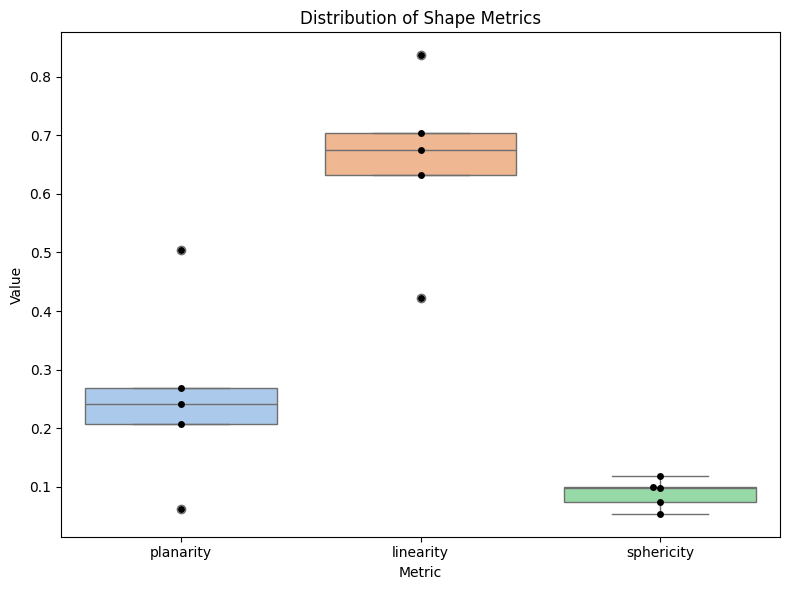

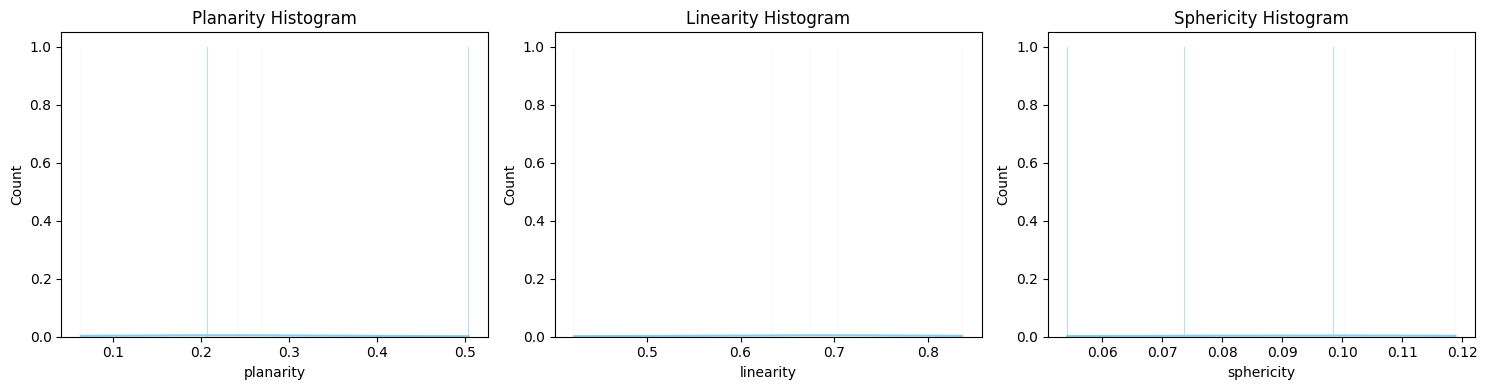

In [228]:
import numpy as np
import napari
from skimage.measure import label, regionprops
from skimage.morphology import remove_small_objects

# ---------------------------
# 0) 네 gradient 함수: 마스크 아무거나 받아서 그라디언트 입혀 보여주도록 일반화
# ---------------------------
def napari_gradient_from_mask(mask_bool, name="Gradient", colormap="twilight",
                              base=0.2, scale=0.8, power=2.0, opacity=0.5):
    """
    mask_bool : (Z,Y,X) boolean mask
    base/scale: 거리 정규화 범위 [base, base+scale]
    power     : 거리 가중치 지수 (2면 더 급격히 어두워짐/밝아짐)
    """
    mask = mask_bool.astype(np.float32)
    if mask.size == 0 or mask.max() == 0:
        return None, None  # 빈 마스크일 때

    # 중심좌표
    z0, y0, x0 = np.array(mask.shape) / 2
    zz, yy, xx = np.meshgrid(
        np.arange(mask.shape[0]),
        np.arange(mask.shape[1]),
        np.arange(mask.shape[2]),
        indexing="ij"
    )
    distance = np.sqrt((zz - z0) ** 2 + (yy - y0) ** 2 + (xx - x0) ** 2)
    dmax = distance.max() if distance.max() > 0 else 1.0
    distance_norm = base + scale * (distance / dmax)

    gradient_mask = mask * (distance_norm ** power)
    layer_kwargs = dict(name=name, colormap=colormap, blending="translucent", opacity=opacity)
    return gradient_mask.astype(np.float32), layer_kwargs

# ---------------------------
# 1) blob 분류 + napari 시각화
# ---------------------------
def visualize_by_shape(bin3d,
                       min_size=800,
                       connectivity=3,  # 3 => 26-연결(3D)
                       planarity_thr=0.5,
                       linearity_thr=0.3,
                       sphericity_thr=0.2,
                       spacing=None  # (z,y,x) voxel spacing; 등방이면 None
                       ):
    """
    bin3d: (Z,Y,X) boolean mask
    """
    # 안전장치: 너무 작은 거 먼저 제거
    bin3d = remove_small_objects(bin3d.astype(bool), min_size=min_size, connectivity=connectivity)

    # 라벨링
    lab = label(bin3d, connectivity=connectivity)
    print(lab.max())

    # 결과 마스크들
    planar_mask = np.zeros_like(bin3d, dtype=bool)
    linear_mask = np.zeros_like(bin3d, dtype=bool)
    spherical_mask = np.zeros_like(bin3d, dtype=bool)
    other_mask = np.zeros_like(bin3d, dtype=bool)  # 임계 경계 등 분류 애매한 것

    planar_cnt = 0
    linear_cnt = 0
    sphere_cnt = 0
    other_cnt = 0

    metrics_dict = {}
    idx = 0
    for r in regionprops(lab):
        coords = np.array(r.coords)  # (N,3) in (z,y,x)

        # spacing 보정 (비등방일 때 권장)
        if spacing is not None:
            coords_scaled = coords * np.array(spacing)[None, :]
        else:
            coords_scaled = coords

        # 공분산 + 고유값
        X = coords_scaled - coords_scaled.mean(0)
        C = np.cov(X.T)            # 3x3
        w, _ = np.linalg.eigh(C)   # 오름차순
        e1, e2, e3 = w[::-1]       # e1>=e2>=e3

        # 지표
        eps = 1e-8
        planarity = (e2 - e3) / (e1 + eps)   # plate ↑
        linearity = (e1 - e2) / (e1 + eps)   # line  ↑
        sphericity = (e3) / (e1 + eps)       # sphere↑ (상대적)

        metrics_dict[f"R{idx}"] = {
            "planarity": planarity,
            "linearity": linearity,
            "sphericity": sphericity
        }
        idx += 1

        # 분류 규칙 (필요하면 튜닝)
        lbl = r.label
        if (planarity > planarity_thr) and (linearity < linearity_thr) and (sphericity < sphericity_thr):
            planar_mask[lab == lbl] = True
            planar_cnt += 1
        elif (linearity > planarity_thr) and (sphericity < sphericity_thr):
            # 선형은 e1만 크고 e2,e3 작음 → linearity가 매우 큰 편
            linear_mask[lab == lbl] = True
            linear_cnt += 1
        elif (sphericity > sphericity_thr) and (linearity < linearity_thr):
            spherical_mask[lab == lbl] = True
            sphere_cnt += 1
        else:
            other_mask[lab == lbl] = True
            other_cnt += 1        

    print(f"planar: {planar_cnt}")
    print(f"linear: {linear_cnt}")
    print(f"sphereical: {sphere_cnt}")
    print(f"other: {other_cnt}")

    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns

    # dict → DataFrame
    df = pd.DataFrame(metrics_dict).T.reset_index().rename(columns={"index": "Region"})
    df_melted = df.melt(id_vars="Region", var_name="Metric", value_name="Value")

    # Boxplot + swarmplot
    plt.figure(figsize=(8, 6))
    sns.boxplot(x="Metric", y="Value", data=df_melted, palette="pastel")
    sns.swarmplot(x="Metric", y="Value", data=df_melted, color="black", size=5)
    plt.title("Distribution of Shape Metrics")
    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for i, metric in enumerate(["planarity", "linearity", "sphericity"]):
        sns.histplot(df[metric], bins=1000, kde=True, ax=axes[i], color="skyblue")
        axes[i].set_title(f"{metric.capitalize()} Histogram")
    plt.tight_layout()
    plt.show()


    # napari viewer
    viewer = napari.Viewer()

    # 각 클래스별로 네 gradient 시각화 함수 재사용
    layers = []

    arr, kw = napari_gradient_from_mask(planar_mask, name="Planar (plates)", colormap="magma", opacity=0.7)
    if arr is not None:
        viewer.add_image(arr, **kw); layers.append(("planar", arr))

    arr, kw = napari_gradient_from_mask(linear_mask, name="Linear (filaments)", colormap="viridis", opacity=0.6)
    if arr is not None:
        viewer.add_image(arr, **kw); layers.append(("linear", arr))

    arr, kw = napari_gradient_from_mask(spherical_mask, name="Spherical (blobs)", colormap="plasma", opacity=0.6)
    if arr is not None:
        viewer.add_image(arr, **kw); layers.append(("spherical", arr))

    # 분류 안 된 나머지도 보고 싶다면 주석 해제
    arr, kw = napari_gradient_from_mask(other_mask, name="Other/uncertain", colormap="gray", opacity=0.4)
    if arr is not None:
        viewer.add_image(arr, **kw); layers.append(("other", arr))

    napari.run()
    return dict(planar=planar_mask, linear=linear_mask, spherical=spherical_mask, other=other_mask)

# ---------------------------
# 사용 예시
# ---------------------------
# bin3d = ...  # (Z,Y,X) boolean mask
result_masks = visualize_by_shape(plane,
                                  min_size=0,
                                  connectivity=3,
                                  planarity_thr=0.5,
                                  linearity_thr=0.5,
                                  sphericity_thr=0.2,
                                  spacing=None)  # e.g., (z_spacing, y_spacing, x_spacing)


### Binarize

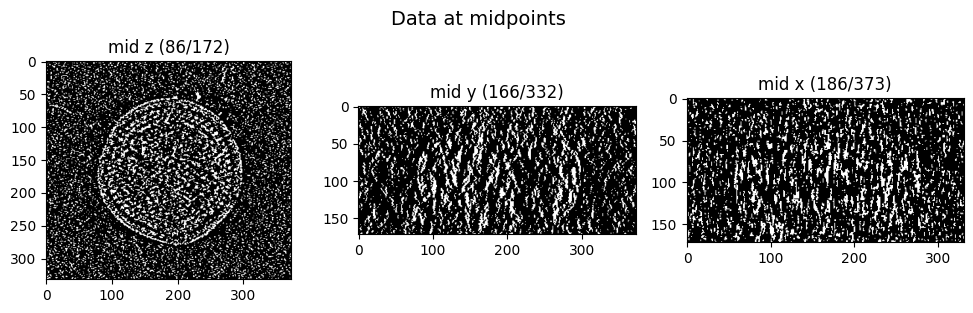

In [16]:
binary_data = np.where(bandpass > 0.8, 1, 0)
visualize_zyx_midslice(binary_data)

### Erosion-Dilation